In [1]:
import os
import simo
from simo import load_data, process_anndata, find_marker, alignment_1, assign_coord_1
from simo.regulation import regulation_analysis, spatial_regulation
from simo import sdplot, sfplot, cor_plot, module_vilolin_plot, module_dot_plot, module_pca_plot, module_spatial_plot, module_heatmap_plot, spatial_lineplot, plot_3d
from simo.helper import extract_reduction
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import itertools
from tqdm import tqdm
import random
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import issparse
import scipy
from scanpy import AnnData
import time

import warnings
warnings.filterwarnings("ignore")

In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    #torch.manual_seed(seed)
    #if torch.cuda.is_available():
    #    torch.cuda.manual_seed_all(seed)
    
    
def integer_allocation(prop, counts):
    expected_cells = prop * counts[:, None]
    int_cells = np.floor(expected_cells).astype(int)
    frac_cells = expected_cells - int_cells
    remaining_cells = counts - int_cells.sum(axis=1)
    for i in range(len(counts)):
        frac_order = np.argsort(-frac_cells[i])
        for j in range(remaining_cells[i]):
            int_cells[i, frac_order[j]] += 1
    return int_cells


def jitter_coord(coord):
    # cell number
    num = coord.shape[0]
    # min distance
    coord_unique = np.unique(coord, axis=0)
    nbrs = NearestNeighbors(n_neighbors=2).fit(coord_unique)
    distances, indices = nbrs.kneighbors(coord_unique)
    min_distance = min(distances[:, -1][distances[:, -1] > 0])

    x_list = list(coord[:, 0])
    y_list = list(coord[:, 1])

    set_seed(0)
    length = np.random.uniform(0, min_distance, num)
    radius = np.pi * np.random.uniform(0, 2, num)

    x_list_new = x_list + length * np.cos(radius)
    y_list_new = y_list + length * np.sin(radius)
    coord_new = np.array([[x_list_new[i], y_list_new[i]] for i in range(num)])

    return coord_new


def adjust_abundance(
    adata_st: AnnData,
    adata_sc: AnnData,
    celltype_key: str = 'celltype',
):
    celltype_unique = sorted(set(adata_sc.obs[celltype_key]))
    
    cell_counts = np.array(adata_st.obs['estimated_cell_number'])
    prop = np.array(adata_st.obs[celltype_unique].copy())
    map_target = integer_allocation(prop, cell_counts)
    
    target_num_list = map_target.sum(axis=0)
    sc_num_list = np.array(adata_sc.obs[celltype_key].value_counts()[celltype_unique])
    diff_num_list = sc_num_list - target_num_list
    
    adata_list = []
    for i in range(len(celltype_unique)):
        adata_tmp = adata_sc[adata_sc.obs[celltype_key] == celltype_unique[i]].copy()
        adata_list.append(adata_tmp)
        
    print(f"Adjust abundance of each cell types")
    for i in tqdm(range(len(celltype_unique))):
        adjust_num = diff_num_list[i]
        adata_tmp = adata_list[i].copy()
        if adjust_num >= 0:
            set_seed(0)
            selected_indices = np.random.choice(adata_tmp.shape[0], size=target_num_list[i], replace=False)
            adata_tmp = adata_tmp[selected_indices]
        elif adjust_num < 0:
            fold = np.abs(diff_num_list[i]) / sc_num_list[i]
            if fold > 1:
                fold_int = int(fold)
                selected_indices = list(range(adata_tmp.shape[0])) * fold_int
                set_seed(0)
                selected_indices2 = list(
                    np.random.choice(adata_tmp.shape[0], size=(np.abs(diff_num_list[i]) - fold_int * adata_tmp.shape[0]), replace=False)
                )
                selected_indices.extend(selected_indices2)
                selected_indices = np.array(selected_indices)
            else:
                set_seed(0)
                selected_indices = np.random.choice(adata_tmp.shape[0], size=np.abs(diff_num_list[i]), replace=False)
            
            adata_tmp_replicate = adata_tmp[selected_indices].copy()
            adata_tmp = sc.concat([adata_tmp, adata_tmp_replicate]).copy()
            
        adata_list[i] = adata_tmp.copy()
        
    adata_sc_new = sc.concat(adata_list).copy()
    adata_sc_new.obs_names_make_unique()
    print(f"Done")
    
    return adata_st, adata_sc_new


def process_result(
    adata_st: AnnData,
    adata_sc: AnnData,
    transport_matrix: np.array,
    celltype_key: str = 'celltype',
):
    
    print(f"Assign cells")
    spot_to_cells = []
    cell_counts = adata_st.obs['estimated_cell_number']
    for i in tqdm(range(transport_matrix.shape[1])):
        k = int(cell_counts[i])
        top_k_cells = np.argsort(-transport_matrix[:, i])[:k]
        spot_to_cells.append(list(top_k_cells))
        
    print(f"Create new data")
    if issparse(adata_sc.X):
        adata_sc.X = adata_sc.X.toarray()
        
    # original
    original_spot = list(adata_st.obs_names)
    original_cell = list(adata_sc.obs_names)
    original_celltype = list(adata_sc.obs[celltype_key])
    original_x = list(adata_st.obsm['spatial'][:, 0])
    original_y = list(adata_st.obsm['spatial'][:, 1])
    original_expr = adata_sc.X
    
    # new
    cell_list = []
    celltype_list = []
    spot_list = []
    x_list = []
    y_list = []
    expr_list = []
    
    for i, indices in enumerate(spot_to_cells):
        cell_list.extend(original_cell[idx] for idx in indices)
        celltype_list.extend(original_celltype[idx] for idx in indices)

        spot_list.extend([original_spot[i]] * len(indices))
        x_list.extend([original_x[i]] * len(indices))
        y_list.extend([original_y[i]] * len(indices))

        expr_list.extend(original_expr[indices])
        
    new_id_list = ['CID' + str(i + 1) for i in range(len(cell_list))]
    
    new_meta = pd.DataFrame({
        'NewCID': new_id_list,
        'OriginalCID': cell_list,
        'CellType': celltype_list,
        'SpotID': spot_list,
        'X': x_list,
        'Y': y_list,
    })
    
    new_meta.index = new_id_list
    new_expr = np.array(expr_list)
    new_expr = scipy.sparse.csr_matrix(new_expr)
    coord = np.array(new_meta[['X', 'Y']])
    coord_jitter = jitter_coord(coord)
    
    new_meta['X_jitter'] = coord_jitter[:, 0]
    new_meta['Y_jitter'] = coord_jitter[:, 1]

    # new AnnData
    adata_new = sc.AnnData(new_expr)
    adata_new.obs = new_meta
    adata_new.obs_names = new_id_list
    adata_new.var_names = adata_sc.var_names
    adata_new.obsm['spatial'] = coord_jitter
    
    print("Done")
    return adata_new

In [3]:
sc_adata = sc.read('../processed/sc_adata.h5ad')
st_adata = sc.read('../processed/st_adata.h5ad')

In [4]:
sc_adata

AnnData object with n_obs × n_vars = 15603 × 17003
    obs: 'sample_id', 'sample_type', 'organism', 'donor', 'sex', 'age_days', 'brain_hemisphere', 'brain_region', 'brain_subregion', 'facs_date', 'facs_container', 'facs_sort_criteria', 'rna_amplification_set', 'library_prep_set', 'library_prep_avg_size_bp', 'seq_name', 'seq_tube', 'seq_batch', 'total_reads', 'percent_exon_reads', 'percent_intron_reads', 'percent_intergenic_reads', 'percent_rrna_reads', 'percent_mt_exon_reads', 'percent_reads_unique', 'percent_synth_reads', 'percent_ecoli_reads', 'percent_aligned_reads_total', 'complexity_cg', 'genes_detected_cpm_criterion', 'genes_detected_fpkm_criterion', 'class', 'cluster', 'celltype', 'n_genes'
    var: 'n_cells'

In [5]:
st_adata

AnnData object with n_obs × n_vars = 3611 × 17003
    obs: 'in_tissue', 'array_row', 'array_col', 'domain', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'domain_colors', 'spatial'
    obsm: 'spatial'

In [6]:
def pre_filter(
        adata_st: AnnData,
        adata_sc: AnnData,

):
    # if issparse(adata_sc.X):
    #     adata_sc.X = adata_sc.X.toarray()
    # if issparse(adata_st.X):
    #     adata_st.X = adata_st.X.toarray()
        
    adata_sc.var_names_make_unique()
    adata_st.var_names_make_unique()

    # filter genes, cells, and spots
    print(f"Filter data")
    sc.pp.filter_cells(adata_sc, min_genes=1)
    sc.pp.filter_genes(adata_sc, min_cells=1)
    sc.pp.filter_cells(adata_st, min_genes=1)
    sc.pp.filter_genes(adata_st, min_cells=1)
    print(f"Done")
    
    return adata_sc, adata_st


# run
start_time = time.time()
sc_adata, st_adata = pre_filter(
    adata_st=st_adata.copy(),
    adata_sc=sc_adata.copy(),
)
end_time = time.time()
print(f"Filter step time: {end_time - start_time:.2f} seconds")

Filter data
Done
Filter step time: 2.76 seconds


Estimating based on normalized data
Done
Estimated cell number step time: 0.24 seconds


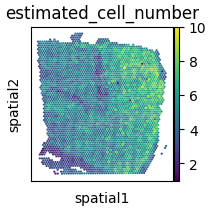

In [7]:
def estimate_cell_number(
        adata,
        mean_cell_numbers,
        normalize: bool = True,
):
    """

    :param adata_st:
    :param mean_cell_numbers:
    :return:
    """
    assert mean_cell_numbers > 0, 'Mean cell number must be positive!'

    adata_use = adata.copy()
    if normalize:
        print('Estimating based on normalized data')
        sc.pp.normalize_total(adata_use, target_sum=1e6)
        sc.pp.log1p(adata_use)
        
    if issparse(adata_use.X):
        adata_use.X = adata_use.X.toarray()
    
    expr = adata_use.X.T.astype(float)

    # Set up fitting problem
    RNA_reads = np.sum(expr, axis=0, dtype=float)
    mean_RNA_reads = np.mean(RNA_reads)
    min_RNA_reads = np.min(RNA_reads)

    min_cell_numbers = 1 if min_RNA_reads > 0 else 0

    fit_parameters = np.polyfit(np.array([min_RNA_reads, mean_RNA_reads]),
                                np.array([min_cell_numbers, mean_cell_numbers]), 1)
    polynomial = np.poly1d(fit_parameters)
    estimated_cell_number = np.round(polynomial(RNA_reads)).astype(int)
    adata.obs['estimated_cell_number'] = estimated_cell_number
    print(f"Done")
    
    return adata


# run
start_time = time.time()
st_adata = estimate_cell_number(
    adata=st_adata.copy(),
    mean_cell_numbers=5,
    normalize=True,
)
end_time = time.time()
print(f"Estimated cell number step time: {end_time - start_time:.2f} seconds")

plt.rcParams["figure.figsize"] = (2, 2)
sc.pl.embedding(st_adata, basis='spatial', color='estimated_cell_number', s=10)

In [8]:
# load deconvolution results
prop = pd.read_csv('../results/C2L_res.csv', index_col=0)
ct_sort = sorted(set(sc_adata.obs['celltype']))
prop = prop[ct_sort]
prop = prop.loc[st_adata.obs_names]
obs_raw = st_adata.obs.copy()
obs_new = pd.concat([obs_raw, prop], axis=1)
st_adata.obs = obs_new

In [9]:
st_adata, sc_adata = adjust_abundance(
            adata_st = st_adata.copy(),
            adata_sc = sc_adata.copy(),
            celltype_key='celltype',
        )

Adjust abundance of each cell types


100%|██████████| 7/7 [00:00<00:00,  7.25it/s]


Done


In [10]:
sc.tl.pca(sc_adata, n_comps=30)
sc_adata.obsm['reduction'] = sc_adata.obsm['X_pca'].copy()
sc_adata.obs['type'] = sc_adata.obs['celltype'].copy()
st_adata.obs['type'] = 'uniform_region'
expected_num = st_adata.obs['estimated_cell_number']
expected_num = pd.DataFrame(expected_num)
expected_num.columns = ['cell_num']

In [11]:
sc_adata = process_anndata(sc_adata)
st_adata = process_anndata(st_adata)

Processing RNA data...
Identifying highly variable genes...
Normalizing total counts...
Applying log1p transformation...
Saving pre-log1p counts to a layer...
Scaling the data...
Performing PCA...
Calculating neighbors based on cosine metric...
Performing UMAP...
Processing completed.
Processing RNA data...
Identifying highly variable genes...
Normalizing total counts...
Applying log1p transformation...
Saving pre-log1p counts to a layer...
Scaling the data...
Performing PCA...
Calculating neighbors based on cosine metric...
Performing UMAP...
Processing completed.


In [12]:
alignment_result = alignment_1(adata1=st_adata, adata2=sc_adata, alpha=0.1, aware_st=False, aware_sc=True)
spatial_assignment = assign_coord_1(adata1=st_adata, adata2=sc_adata, out_data=alignment_result, non_zero_probabilities=True, no_repeated_cells=True, expected_num=expected_num, pos_random=False)

adata_new = sc_adata[spatial_assignment['cell'], :]
spatial_assignment = spatial_assignment.set_index('cell')
adata_new.obs[['SpotID', 'x_simo', 'y_simo']] = spatial_assignment[['spot', 'Cell_xcoord', 'Cell_ycoord']]
adata_new.obs['SpotID'] = adata_new.obs['SpotID'].astype(str)
adata_new.var_names = [item.upper() for item in adata_new.var_names]
adata_new.write('../results/SIMO_result.h5ad')

Calculating dissimilarity using euclidean distance on scaled data...
Processing RNA data...
Identifying highly variable genes...
Normalizing total counts...
Applying log1p transformation...
Saving pre-log1p counts to a layer...
Scaling the data...
Processing completed.
Constructing connectivity...
k = 10
aware_sc = True
aware power = 2
Running OT...
alpha = 0.1
OT done!
Assigning spatial coordinates to cells...
random = False
Determine the number of cells allocated to each spot based on the input information
There are 3611 spots and 3611 of them were assigned cells.
Assignment done!


In [13]:
adata_new

AnnData object with n_obs × n_vars = 16099 × 17003
    obs: 'sample_id', 'sample_type', 'organism', 'donor', 'sex', 'age_days', 'brain_hemisphere', 'brain_region', 'brain_subregion', 'facs_date', 'facs_container', 'facs_sort_criteria', 'rna_amplification_set', 'library_prep_set', 'library_prep_avg_size_bp', 'seq_name', 'seq_tube', 'seq_batch', 'total_reads', 'percent_exon_reads', 'percent_intron_reads', 'percent_intergenic_reads', 'percent_rrna_reads', 'percent_mt_exon_reads', 'percent_reads_unique', 'percent_synth_reads', 'percent_ecoli_reads', 'percent_aligned_reads_total', 'complexity_cg', 'genes_detected_cpm_criterion', 'genes_detected_fpkm_criterion', 'class', 'cluster', 'celltype', 'n_genes', 'type', 'SpotID', 'x_simo', 'y_simo'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'pca', 'hvg', 'log1p', 'neighbors', 'umap'
    obsm: 'X_pca', 'reduction', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'data'
    obsp: '

In [14]:
sc_adata

AnnData object with n_obs × n_vars = 18052 × 17003
    obs: 'sample_id', 'sample_type', 'organism', 'donor', 'sex', 'age_days', 'brain_hemisphere', 'brain_region', 'brain_subregion', 'facs_date', 'facs_container', 'facs_sort_criteria', 'rna_amplification_set', 'library_prep_set', 'library_prep_avg_size_bp', 'seq_name', 'seq_tube', 'seq_batch', 'total_reads', 'percent_exon_reads', 'percent_intron_reads', 'percent_intergenic_reads', 'percent_rrna_reads', 'percent_mt_exon_reads', 'percent_reads_unique', 'percent_synth_reads', 'percent_ecoli_reads', 'percent_aligned_reads_total', 'complexity_cg', 'genes_detected_cpm_criterion', 'genes_detected_fpkm_criterion', 'class', 'cluster', 'celltype', 'n_genes', 'type'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'pca', 'hvg', 'log1p', 'neighbors', 'umap'
    obsm: 'X_pca', 'reduction', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'data'
    obsp: 'distances', 'connectivities'

In [15]:
spatial_assignment

,spot,value,spot_type,cell_type,x,y,Cell_xcoord,Cell_ycoord
cell,,,,,,,,
F1S4_160831_141_G01,AAACAAGTATCTCCCA-1,0.000055,uniform_region,Exc,9791,8468,9726.307864,8444.744423
F1S4_160721_135_E01,AAACAAGTATCTCCCA-1,0.000055,uniform_region,Exc,9791,8468,9785.767428,8485.102714
F2S4_160421_043_D01,AAACAAGTATCTCCCA-1,0.000055,uniform_region,Exc,9791,8468,9820.892945,8453.740128
F1S4_160721_118_F01,AAACAAGTATCTCCCA-1,0.000055,uniform_region,Exc,9791,8468,9800.651963,8476.166947
F2S4_160421_064_C01,AAACAAGTATCTCCCA-1,0.000055,uniform_region,Exc,9791,8468,9821.379801,8480.245789
...,...,...,...,...,...,...,...,...
F2S4_160113_058_H01,TTGTTTGTGTAAATTC-1,0.000055,uniform_region,Exc,6317,3291,6306.109263,3288.062452
F1S4_170125_012_F01,TTGTTTGTGTAAATTC-1,0.000055,uniform_region,Inh,6317,3291,6378.881874,3261.057921
F1S4_170106_014_B01,TTGTTTGTGTAAATTC-1,0.000055,uniform_region,Inh,6317,3291,6290.998458,3301.911274
